# Customer Segmentation Using Machine Learning

## 1. Introduction

The objective of this project is to develop a machine learning model
that predicts the customer segment of a customer based on demographic,
educational, professional, family and spending-related characteristics.

The dataset contains four customer segments: A, B, C and D.

Since the training dataset contains the target variable `Segmentation`,
this project is a supervised machine learning problem.

Since `Segmentation` contains four possible classes, this is a
multiclass classification problem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Loading and Understanding the Dataset

The training and testing datasets are loaded using Pandas. The training
dataset contains the target variable `Segmentation`, while the testing
dataset does not contain this variable.

We inspect the first few records and the dimensions of both datasets
to understand their structure before performing data preprocessing.

In [2]:
train_df = pd.read_csv("../data/raw/Train.csv")
test_df = pd.read_csv("../data/raw/Test.csv")

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

train_df.head()

Training data shape: (8068, 11)
Testing data shape: (2627, 10)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


## 3. Inspecting Columns and Data Types

We inspect the column names and data types of the training dataset.
This helps us identify numerical and categorical features and understand
which columns may require preprocessing before applying machine learning
algorithms.

In [3]:
print("Column names:")
print(train_df.columns)

print("\nData types:")
print(train_df.dtypes)

Column names:
Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='str')

Data types:
ID                   int64
Gender                 str
Ever_Married           str
Age                  int64
Graduated              str
Profession             str
Work_Experience    float64
Spending_Score         str
Family_Size        float64
Var_1                  str
Segmentation           str
dtype: object


## 4. Checking Missing Values

Missing values can affect machine learning models and may need to be
handled before training. We calculate the number of missing values in
each column to determine where preprocessing is required.

In [4]:
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in testing data:")
print(test_df.isnull().sum())

Missing values in training data:
ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64

Missing values in testing data:
ID                   0
Gender               0
Ever_Married        50
Age                  0
Graduated           24
Profession          38
Work_Experience    269
Spending_Score       0
Family_Size        113
Var_1               32
dtype: int64


## 5. Missing Value Analysis

The dataset contains missing values in both numerical and categorical features.
Before training machine learning models, these missing values must be handled appropriately.

Instead of removing rows, we will analyze the percentage of missing values in each column and choose a suitable imputation technique.

missing_values = train_df.isnull().sum()

missing_percentage = (missing_values / len(train_df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage.round(2)
})

missing_df[missing_df["Missing Values"] > 0]

## 6. Checking Duplicate Records

Duplicate records can introduce repeated observations into the dataset.
We check whether any duplicate rows exist before preprocessing.

In [5]:
duplicates = train_df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


## 7. Identifying Numerical and Categorical Features

The dataset contains both numerical and categorical variables.
Separating them helps apply different preprocessing techniques to each type of feature.

In [6]:
numerical_cols = train_df.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = train_df.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(numerical_cols)

print("\nCategorical Features:")
print(categorical_cols)

Numerical Features:
Index(['ID', 'Age', 'Work_Experience', 'Family_Size'], dtype='str')

Categorical Features:
Index(['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score',
       'Var_1', 'Segmentation'],
      dtype='str')


C:\Users\user\AppData\Local\Temp\ipykernel_9340\1891825277.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include=["object"]).columns


## 8. Customer Segment Distribution

The target variable `Segmentation` contains four customer segments: A, B, C and D.

We examine the number of customers in each segment to understand the distribution of the target classes. This is important because a highly imbalanced target can affect model performance and make accuracy less reliable.

Segmentation
D    2268
A    1972
C    1970
B    1858
Name: count, dtype: int64


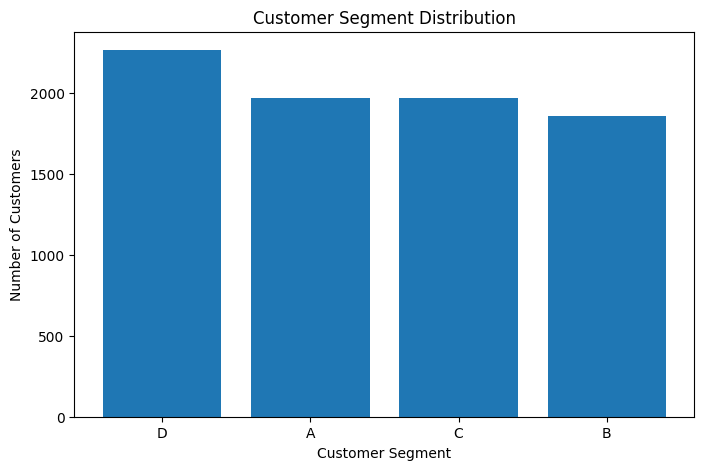

In [7]:
segment_counts = train_df["Segmentation"].value_counts()

print(segment_counts)

plt.figure(figsize=(8, 5))
plt.bar(segment_counts.index, segment_counts.values)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

## 9. Numerical Feature Distribution

We visualize the numerical features to understand their distributions and identify unusual values that may require further investigation.

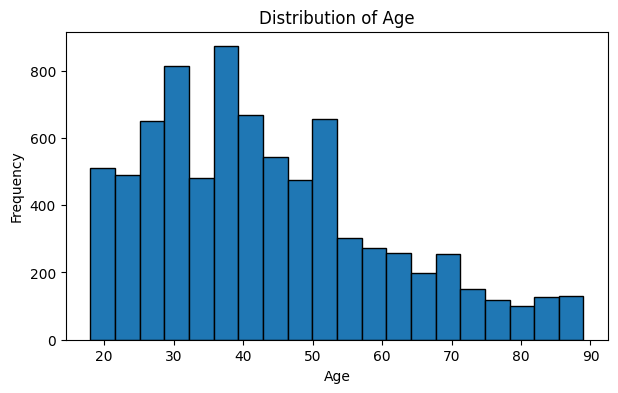

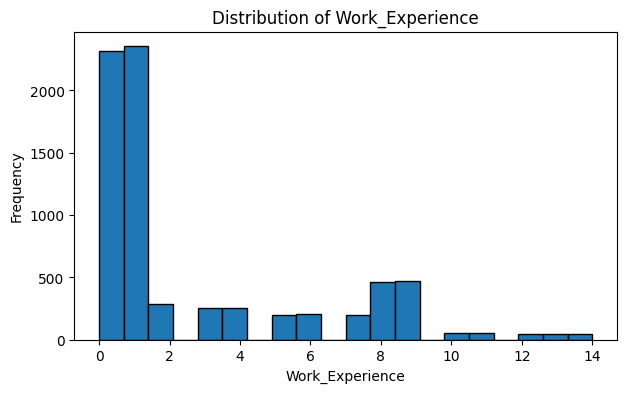

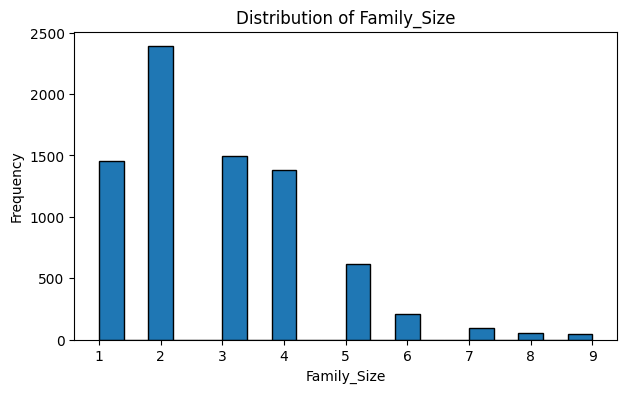

In [8]:
numerical_features = ["Age", "Work_Experience", "Family_Size"]

for feature in numerical_features:
    plt.figure(figsize=(7, 4))
    plt.hist(train_df[feature].dropna(), bins=20, edgecolor="black")
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

## 10. Outlier Detection

Box plots are used to identify potential outliers in the numerical features. This helps us decide whether any unusual values need to be handled during preprocessing.

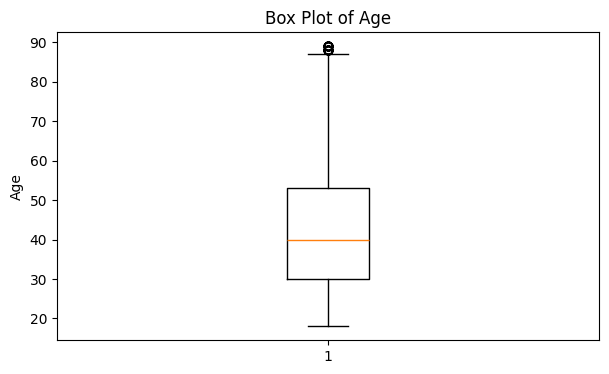

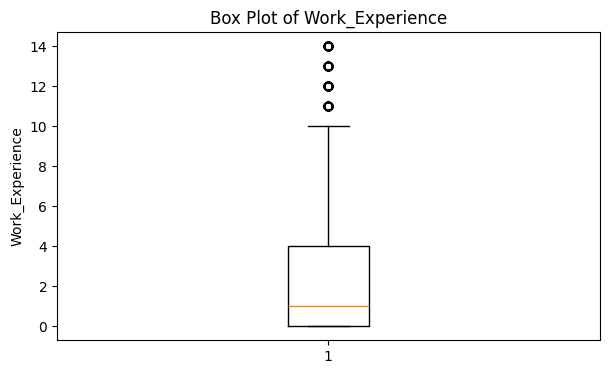

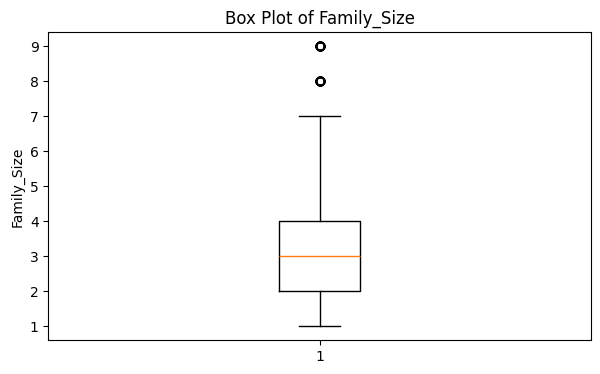

In [9]:
for feature in numerical_features:
    plt.figure(figsize=(7, 4))
    plt.boxplot(train_df[feature].dropna())
    plt.title(f"Box Plot of {feature}")
    plt.ylabel(feature)
    plt.show()

## 11. Categorical Feature Distribution

We examine the categorical features to understand the different categories present in the dataset and how frequently they occur.

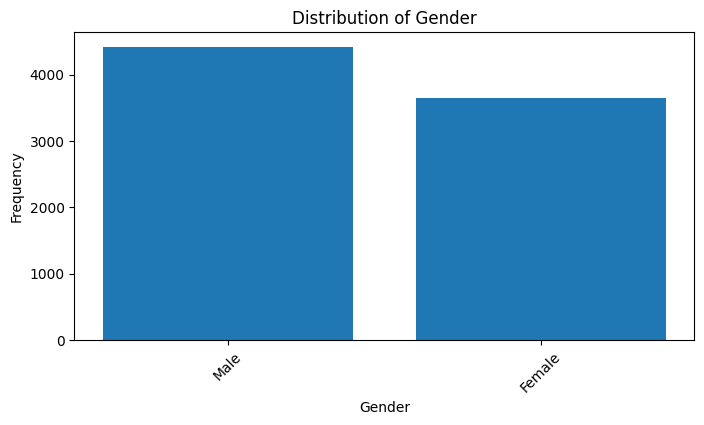

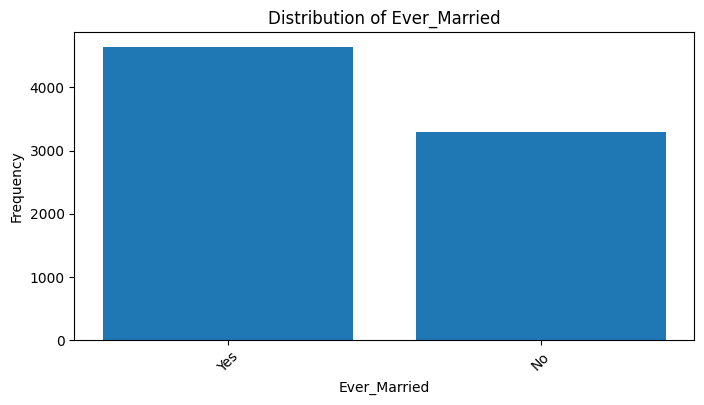

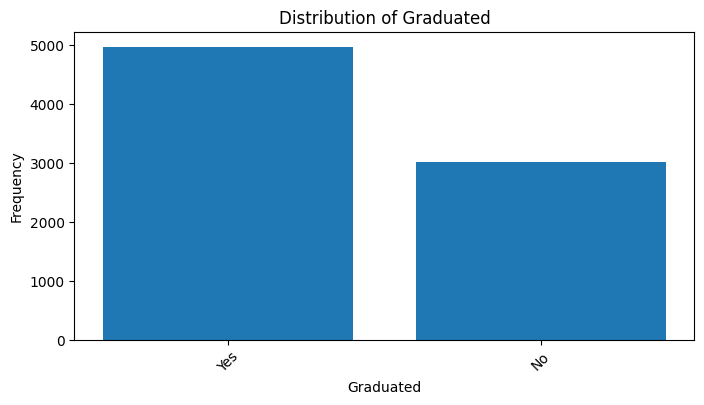

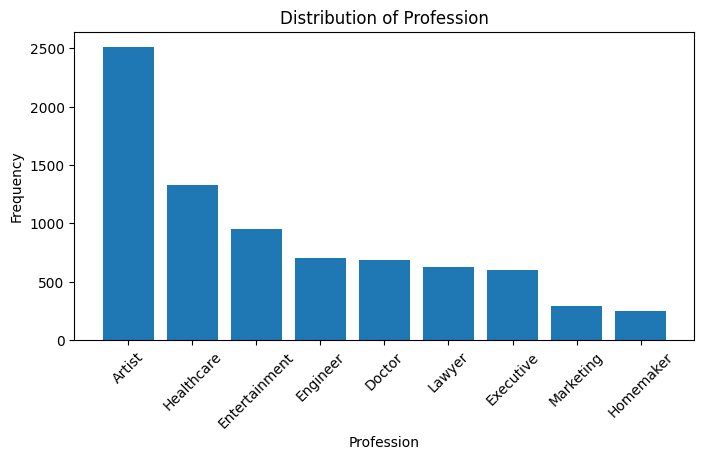

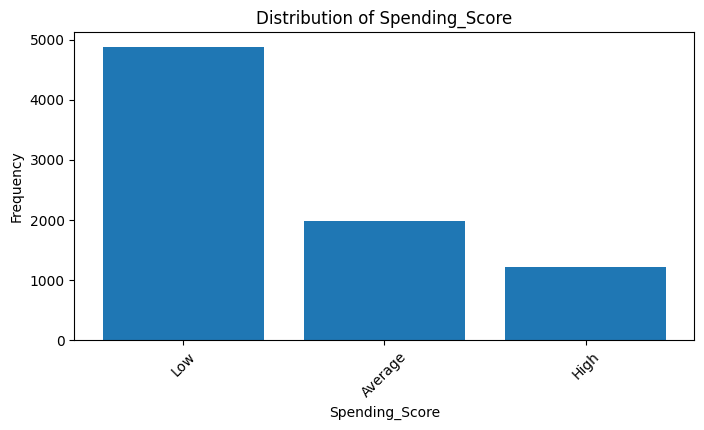

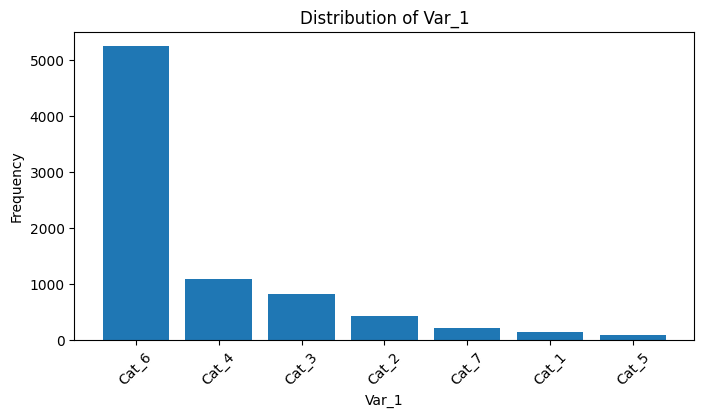

In [10]:
categorical_features = [
    "Gender",
    "Ever_Married",
    "Graduated",
    "Profession",
    "Spending_Score",
    "Var_1"
]

for feature in categorical_features:
    counts = train_df[feature].value_counts()

    plt.figure(figsize=(8, 4))
    plt.bar(counts.index.astype(str), counts.values)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)

    plt.show()

## 12. Removing the Customer ID

The `ID` column is a unique identifier for each customer and does not provide meaningful information about the customer's characteristics. Therefore, it is removed before model training.

In [11]:
train_df = train_df.drop("ID", axis=1)
test_df = test_df.drop("ID", axis=1)

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (8068, 10)
Testing data shape: (2627, 9)


## 13. Handling Missing Values

Missing values are handled differently based on the type of feature.

For numerical features, the median is used because it is less affected by extreme values. For categorical features, the most frequent category (mode) is used.

In [12]:
numerical_features = ["Age", "Work_Experience", "Family_Size"]

categorical_features = [
    "Gender",
    "Ever_Married",
    "Graduated",
    "Profession",
    "Spending_Score",
    "Var_1"
]

for feature in numerical_features:
    train_df[feature] = train_df[feature].fillna(train_df[feature].median())
    test_df[feature] = test_df[feature].fillna(train_df[feature].median())

for feature in categorical_features:
    train_df[feature] = train_df[feature].fillna(train_df[feature].mode()[0])
    test_df[feature] = test_df[feature].fillna(train_df[feature].mode()[0])

## 14. Encoding Categorical Features

Machine learning models require numerical input, but the dataset contains categorical features such as Gender, Profession and Spending_Score.

One-hot encoding converts each category into a separate binary column containing 0 or 1.

In [13]:
from sklearn.preprocessing import OneHotEncoder

In [14]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded_train = encoder.fit_transform(train_df[categorical_features])
encoded_test = encoder.transform(test_df[categorical_features])

## 15. Combining Processed Features

After encoding the categorical features, we combine them with the numerical features to create the final feature dataset that will be given to the machine learning models.

In [15]:
numerical_train = train_df[numerical_features].to_numpy()
numerical_test = test_df[numerical_features].to_numpy()

X_train = np.hstack((numerical_train, encoded_train))
X_test = np.hstack((numerical_test, encoded_test))

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

Training features shape: (8068, 28)
Testing features shape: (2627, 28)


## 16. Separating the Target Variable

The `Segmentation` column is the target variable that we want the machine learning models to predict. We separate it from the input features.

In [16]:
y = train_df["Segmentation"]

print("Target shape:", y.shape)
print(y.head())

Target shape: (8068,)
0    D
1    A
2    B
3    B
4    A
Name: Segmentation, dtype: str


## 17. Splitting the Dataset

The training data is divided into a training set and a validation set.
The training set is used to train the models, while the validation set
is used to evaluate their performance on data they have not seen during training.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

Training set: (6454, 28)
Validation set: (1614, 28)


## 18. Feature Scaling

The numerical features have different ranges, so feature scaling is applied to bring the features to a comparable scale. Standardization transforms the features based on their mean and standard deviation.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 19. Logistic Regression

Logistic Regression is used as the first classification model to predict the customer segment based on the processed customer features.

In [27]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_val_scaled)

## 20. Evaluating Logistic Regression

The Logistic Regression model is evaluated on the validation data using accuracy, precision, recall and F1-score.

In [28]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_val, logistic_predictions)

print("Logistic Regression Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_val, logistic_predictions))

Logistic Regression Accuracy: 0.516728624535316

Classification Report:
              precision    recall  f1-score   support

           A       0.42      0.44      0.43       394
           B       0.41      0.25      0.31       372
           C       0.51      0.59      0.55       394
           D       0.64      0.74      0.69       454

    accuracy                           0.52      1614
   macro avg       0.50      0.50      0.49      1614
weighted avg       0.50      0.52      0.50      1614



## 21. Decision Tree

A Decision Tree is a classification algorithm that makes predictions by creating a series of decision rules based on the input features.

In [21]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_val)
#print(tree_predictions)

## 22. Evaluating Decision Tree

The Decision Tree model is evaluated on the validation data using accuracy, precision, recall and F1-score.

In [22]:
tree_accuracy = accuracy_score(y_val, tree_predictions)

print("Decision Tree Accuracy:", tree_accuracy)

print("\nClassification Report:")
print(classification_report(y_val, tree_predictions))

Decision Tree Accuracy: 0.49318463444857497

Classification Report:
              precision    recall  f1-score   support

           A       0.40      0.42      0.41       394
           B       0.37      0.33      0.35       372
           C       0.52      0.53      0.52       394
           D       0.64      0.66      0.65       454

    accuracy                           0.49      1614
   macro avg       0.48      0.48      0.48      1614
weighted avg       0.49      0.49      0.49      1614



## 23. Random Forest

Random Forest is an ensemble classification algorithm that combines multiple decision trees to improve prediction performance and reduce overfitting.

In [23]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_val)

## 24. Evaluating Random Forest

The Random Forest model is evaluated on the validation data using accuracy, precision, recall and F1-score.

In [24]:
random_forest_accuracy = accuracy_score(
    y_val,
    random_forest_predictions
)

print("Random Forest Accuracy:", random_forest_accuracy)

print("\nClassification Report:")
print(classification_report(y_val, random_forest_predictions))

Random Forest Accuracy: 0.49070631970260226

Classification Report:
              precision    recall  f1-score   support

           A       0.40      0.40      0.40       394
           B       0.37      0.34      0.35       372
           C       0.54      0.49      0.51       394
           D       0.61      0.69      0.65       454

    accuracy                           0.49      1614
   macro avg       0.48      0.48      0.48      1614
weighted avg       0.49      0.49      0.49      1614



## 25. Model Comparison

The validation accuracies of the three classification models are compared to identify the best-performing model.

In [29]:
model_comparison = {
    "Logistic Regression": accuracy,
    "Decision Tree": tree_accuracy,
    "Random Forest": random_forest_accuracy
}

for model, score in model_comparison.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.5167
Decision Tree: 0.4932
Random Forest: 0.4907


## 26. Correct Feature Scaling

The scaler is fitted only on the training data to prevent information from the validation set influencing the model. The same scaler is then used to transform the validation and test data.

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 27. Confusion Matrix

The confusion matrix shows the actual customer segments compared with the segments predicted by the Logistic Regression model.

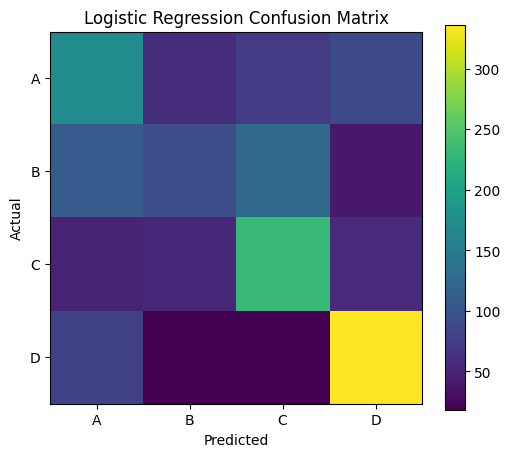

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, logistic_predictions)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks(range(4), ["A", "B", "C", "D"])
plt.yticks(range(4), ["A", "B", "C", "D"])

plt.show()

## 28. Selecting the Best Model

The three classification models are compared using validation accuracy. Logistic Regression achieved the highest validation accuracy and is selected as the final model.

In [31]:
best_model = logistic_model

print("Best Model: Logistic Regression")
print("Validation Accuracy:", accuracy)

Best Model: Logistic Regression
Validation Accuracy: 0.516728624535316


In [32]:
#we use joblib for savintg the model in binary
import joblib

joblib.dump(best_model, "../models/logistic_regression_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [33]:
#also should save the scalar, so we could do the scaling on the test data
joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


## 31. Loading the Test Dataset

The test dataset is loaded for generating final customer segment predictions using the selected Logistic Regression model.

In [34]:
test_df = pd.read_csv("../data/raw/Test.csv")

print("Test data shape:", test_df.shape)

test_df.head()

Test data shape: (2627, 10)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6


## 32. Generating Test Predictions

In [38]:
test_predictions = best_model.predict(X_test_scaled)

print("Test predictions:", test_predictions.shape)

Test predictions: (2627,)


## 33. Adding Predictions to Test Data

In [39]:
test_df["Segmentation"] = test_predictions

test_df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6,A
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6,C
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6,B
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6,A
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6,D


## 34. Saving Predictions

In [40]:
test_df.to_csv("../outputs/test_predictions.csv", index=False)

print("Predictions saved successfully.")

Predictions saved successfully.


## 35. Verifying Predictions

In [41]:
print("Number of predictions:", len(test_predictions))
print("\nPrediction counts:")
print(pd.Series(test_predictions).value_counts())

print("\nOutput shape:", test_df.shape)

Number of predictions: 2627

Prediction counts:
D    794
A    752
C    707
B    374
Name: count, dtype: int64

Output shape: (2627, 11)


## 36. Final Summary

The customer segmentation project was completed using Logistic Regression, Decision Tree, and Random Forest classification models.

Logistic Regression achieved the highest validation accuracy of approximately 51.67% and was selected as the final model.

The final model was used to predict customer segments for the test dataset, and the predictions were saved to `outputs/test_predictions.csv`.

The trained model and scaler were also saved in the `models/` directory for future use.